# Phần 2: Ứng Dụng Data Fitting vào Dữ Liệu Thực Tế

## 2.1. Mục tiêu của bước khảo sát dữ liệu

Trước khi xây dựng mô hình hồi quy, nhóm thực hiện khảo sát dữ liệu ban đầu nhằm hiểu rõ cấu trúc của bộ dữ liệu, kiểu dữ liệu của các biến, mức độ thiếu dữ liệu, phân phối của biến mục tiêu và các đặc trưng, cũng như phát hiện các giá trị ngoại lai có thể ảnh hưởng đến mô hình.

Kết quả của bước khảo sát dữ liệu sẽ được sử dụng để thiết kế pipeline tiền xử lý, bao gồm lựa chọn cột sử dụng, xử lý missing values, mã hóa biến phân loại, chuẩn hóa dữ liệu và xử lý outliers nếu cần.

## 2.2. Tổng quan cấu trúc dữ liệu

Bộ dữ liệu được đọc từ file `Melbourne_housing_FULL.csv`. Trước tiên, nhóm kiểm tra một số dòng đầu, kích thước dữ liệu, kiểu dữ liệu của từng cột và số lượng giá trị không thiếu.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_pipeline import DataPipeline 

Đọc dữ liệu và xuất 5 sample đầu tiên

In [2]:
df = pd.read_csv("data/Melbourne_housing_FULL.csv")
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


Số sample và số feature

In [3]:
df.shape

(34857, 21)

Các feature

In [4]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='str')

Thông tin của feature

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float64
 18  Longtitude     26

Các kiểu dữ liệu của feature

In [6]:
df.dtypes

Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

Bộ dữ liệu gồm nhiều biến mô tả đặc điểm của bất động sản như số phòng, loại nhà, khoảng cách đến trung tâm, diện tích đất, diện tích xây dựng, năm xây dựng, khu vực và giá bán. Trong đó, `Price` là biến mục tiêu của bài toán hồi quy. Dữ liệu bao gồm cả biến số và biến phân loại, do đó cần có các bước xử lý tương ứng trước khi đưa vào mô hình.

## 2.3. Thống kê mô tả

Nhóm sử dụng thống kê mô tả để quan sát các đại lượng cơ bản của các biến số như mean, median, standard deviation, min, max và các quartiles. Việc này giúp nhận diện thang đo của từng biến và phát hiện sơ bộ các giá trị bất thường.

In [7]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


In [8]:
df.describe(include=["object"])

C:\Users\nguye\AppData\Local\Temp\ipykernel_34732\3753758486.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"])


,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,34857,34857,34857,34857,34857,34857,34854,34854
unique,351,34009,3,9,388,78,33,8
top,Reservoir,5 Charles St,h,S,Jellis,28/10/2017,Boroondara City Council,Southern Metropolitan
freq,844,6,23980,19744,3359,1119,3675,11836


Kết quả thống kê mô tả cho thấy các biến số có thang đo khác nhau đáng kể. Ví dụ, `Rooms` và `Bathroom` có giá trị tương đối nhỏ, trong khi `Landsize`, `BuildingArea` và `Propertycount` có miền giá trị rộng hơn nhiều. Điều này cho thấy bước chuẩn hóa dữ liệu là cần thiết trước khi huấn luyện mô hình, đặc biệt đối với các mô hình có regularization như Ridge hoặc Lasso.

## 2.4. Phân tích missing values

Do yêu cầu của đồ án là bộ dữ liệu phải có missing values, nhóm tiến hành kiểm tra số lượng và tỷ lệ giá trị thiếu theo từng cột. Kết quả này giúp lựa chọn chiến lược xử lý missing values phù hợp trong pipeline.

In [9]:
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent (%)": df.isnull().mean() * 100
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table = missing_table.sort_values("Missing Percent (%)", ascending=False)

missing_table

,Missing Count,Missing Percent (%)
BuildingArea,21115,60.576068
YearBuilt,19306,55.386293
Landsize,11810,33.881286
Car,8728,25.039447
Bathroom,8226,23.599277
Bedroom2,8217,23.573457
Longtitude,7976,22.882061
Lattitude,7976,22.882061
Price,7610,21.832057
CouncilArea,3,0.008607


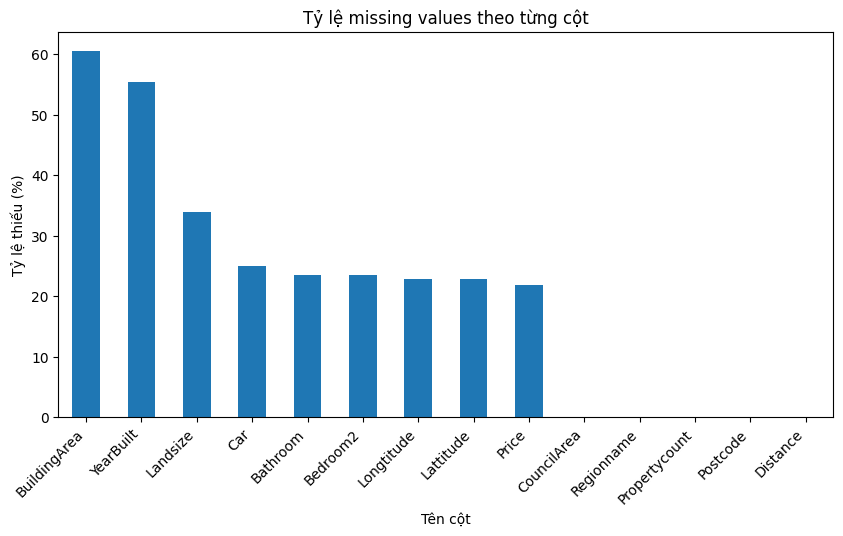

In [10]:
plt.figure(figsize=(10, 5))
missing_table["Missing Percent (%)"].plot(kind="bar")
plt.title("Tỷ lệ missing values theo từng cột")
plt.xlabel("Tên cột")
plt.ylabel("Tỷ lệ thiếu (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

Bảng missing values cho thấy dữ liệu có nhiều cột bị thiếu với tỷ lệ đáng kể, đặc biệt là `BuildingArea`, `YearBuilt`, `Landsize`, `Car`, `Bathroom`, `Bedroom2`, `Lattitude` và `Longtitude`. Ngoài ra, biến mục tiêu `Price` cũng có giá trị thiếu.

Vì `Price` là biến mục tiêu nên các dòng thiếu `Price` không thể sử dụng để huấn luyện mô hình và sẽ được loại bỏ. Đối với các biến đặc trưng, nhóm không xóa toàn bộ dòng thiếu dữ liệu vì điều này có thể làm mất nhiều quan sát. Thay vào đó, nhóm sử dụng median imputation cho biến số và điền `"Unknown"` cho biến phân loại trong `DataPipeline`.

## 2.5. Kiểm tra dữ liệu trùng lặp

Nhóm kiểm tra các dòng dữ liệu trùng lặp hoàn toàn để tránh việc một quan sát xuất hiện nhiều lần và gây sai lệch khi huấn luyện mô hình.

In [11]:
num_duplicates = df.duplicated().sum()
print(f'Số dòng trùng lặp: {num_duplicates}')

Số dòng trùng lặp: 1


In [12]:
df[df.duplicated()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
15858,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,15.4,3131.0,...,3.0,2.0,405.0,226.0,2000.0,Manningham City Council,-37.82678,145.16777,Eastern Metropolitan,4973.0


Nếu tồn tại các dòng trùng lặp hoàn toàn, nhóm sẽ loại bỏ chúng trước khi xây dựng mô hình. Việc loại bỏ duplicate giúp đảm bảo mỗi quan sát chỉ đóng góp một lần vào quá trình huấn luyện.

In [13]:
df = df.drop_duplicates()

In [14]:
print(f'Số dòng trùng lặp: {df.duplicated().sum()}')

Số dòng trùng lặp: 0


## 2.6. Phân tích biến mục tiêu Price

Biến `Price` là biến mục tiêu của bài toán hồi quy, biểu diễn giá bán của bất động sản. Nhóm khảo sát phân phối của biến này để đánh giá độ lệch, sự xuất hiện của outliers và xem xét khả năng cần biến đổi dữ liệu trong bước mô hình hóa.

In [15]:
price_data = df['Price'].dropna()
price_data.describe()

count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64

Dựa trên thống kê mô tả của biến `Price`, ta thấy giá trị median là 870,000 trong khi giá trị lớn nhất lên tới 11,200,000. Giá trị lớn nhất cao hơn median khoảng 12.9 lần, cho thấy dữ liệu có một số bất động sản có giá rất cao so với mặt bằng chung.

Ngoài ra, mean của `Price` là khoảng 1,050,173, lớn hơn median 870,000. Điều này cho thấy phân phối của `Price` có xu hướng lệch phải, tức là một số giá trị lớn đã kéo trung bình lên cao hơn trung vị.

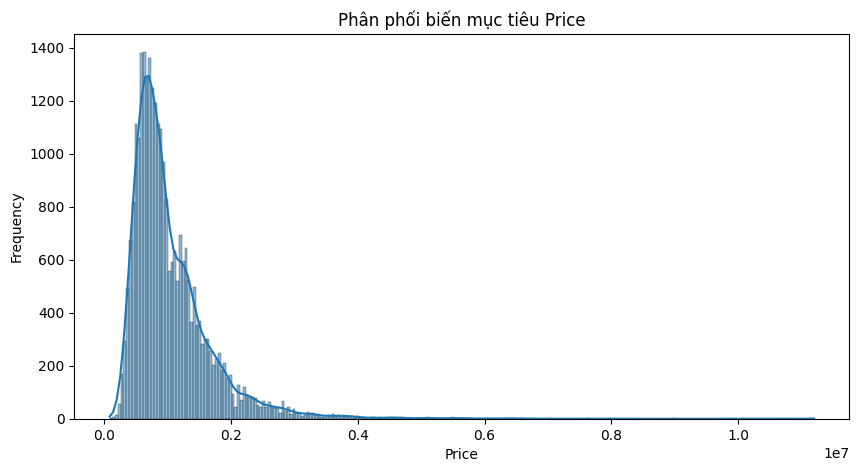

In [16]:
plt.figure(figsize = (10,5))
sns.histplot(price_data, kde = True)
plt.title('Phân phối biến mục tiêu Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Biến `Price` có phân phối lệch phải. Phần lớn bất động sản có giá ở mức thấp hoặc trung bình, trong khi một số ít bất động sản có giá rất cao.

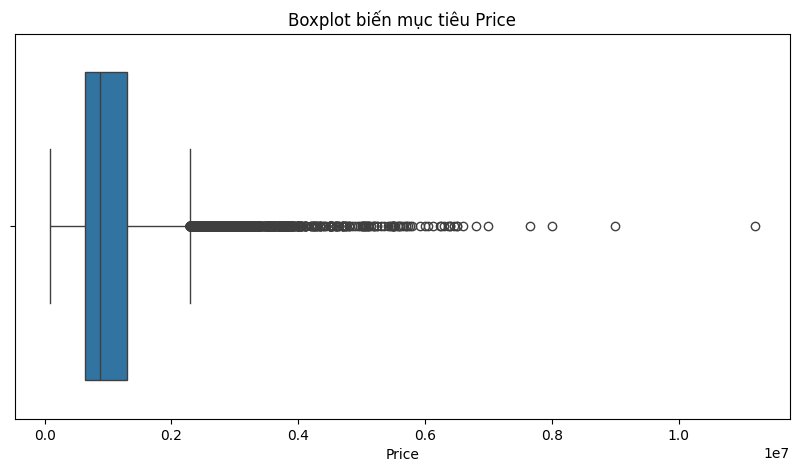

In [17]:
plt.figure(figsize = (10,5))
sns.boxplot(x = price_data)
plt.title('Boxplot biến mục tiêu Price')
plt.xlabel('Price')
plt.show()

Boxplot cho thấy `Price` có nhiều giá trị ngoại lai ở phía giá trị lớn. Điều này hợp lý với dữ liệu bất động sản vì luôn tồn tại một số căn nhà có giá rất cao so với mặt bằng chung.

## 2.7. Phân tích các biến số

Mục tiêu của phần này là khảo sát phân phối của các biến số như `Rooms`, `Distance`, `Landsize` và `BuildingArea`. Nhóm tập trung quan sát độ lệch của phân phối, sự xuất hiện của outliers và sự khác biệt về thang đo giữa các biến.

In [18]:
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
numeric_feature = [col for col in numeric_cols if col != 'Price']
print(f'Các cột số là: {numeric_feature}')

Các cột số là: ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']


In [19]:
df[numeric_feature].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,34856.0,3.031013,0.969947,1.00000,2.00000,3.0000,4.000000,16.00000
Distance,34855.0,11.184808,6.788952,0.00000,6.40000,10.3000,14.000000,48.10000
Postcode,34855.0,3116.062430,109.025437,3000.00000,3051.00000,3103.0000,3156.000000,3978.00000
Bedroom2,26639.0,3.084650,0.980708,0.00000,2.00000,3.0000,4.000000,30.00000
Bathroom,26630.0,1.624747,0.724177,0.00000,1.00000,2.0000,2.000000,12.00000
Car,26128.0,1.728835,1.010789,0.00000,1.00000,2.0000,2.000000,26.00000
Landsize,23046.0,593.607177,3398.915462,0.00000,224.00000,521.0000,670.000000,433014.00000
BuildingArea,13741.0,160.251616,401.281270,0.00000,102.00000,136.0000,188.000000,44515.00000
YearBuilt,15550.0,1965.287653,37.328340,1196.00000,1940.00000,1970.0000,2000.000000,2106.00000
Lattitude,26880.0,-37.810634,0.090281,-38.19043,-37.86295,-37.8076,-37.754092,-37.39020


Bảng thống kê mô tả cho thấy các biến số có thang đo khác nhau đáng kể. Một số biến như `Rooms`, `Bedroom2`, `Bathroom` có miền giá trị nhỏ, trong khi `Landsize`, `BuildingArea` và `Propertycount` có miền giá trị rộng hơn nhiều. Điều này cho thấy bước chuẩn hóa dữ liệu là cần thiết trước khi đưa dữ liệu vào mô hình hồi quy.

## 2.8. Phân tích các biến phân loại

Trong phần này, nhóm khảo sát các biến phân loại trong bộ dữ liệu. Mục tiêu là xác định số lượng nhóm khác nhau của từng biến, từ đó quyết định biến nào phù hợp để mã hóa one-hot và biến nào nên loại bỏ để tránh làm tăng số chiều dữ liệu quá lớn.

In [20]:
categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()
print(f'Các biến phân loại là: {categorical_cols}')

Các biến phân loại là: ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


C:\Users\nguye\AppData\Local\Temp\ipykernel_34732\3491968582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()


In [21]:
category_summary = pd.DataFrame({
    "Column": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols],
    "Missing Count": [df[col].isnull().sum() for col in categorical_cols],
    "Missing Percent (%)": [df[col].isnull().mean() * 100 for col in categorical_cols]
})

category_summary = category_summary.sort_values("Unique Values", ascending=False)
category_summary

,Column,Unique Values,Missing Count,Missing Percent (%)
1,Address,34009,0,0.000000
4,SellerG,388,0,0.000000
0,Suburb,351,0,0.000000
5,Date,78,0,0.000000
6,CouncilArea,33,3,0.008607
3,Method,9,0,0.000000
7,Regionname,8,3,0.008607
2,Type,3,0,0.000000


Bảng thống kê cho thấy một số biến phân loại có số lượng nhóm rất lớn, chẳng hạn như `Address`, `Suburb` và `SellerG`. Nếu mã hóa one-hot trực tiếp các biến này, số chiều dữ liệu sẽ tăng mạnh, làm mô hình OLS trở nên phức tạp hơn và dễ gặp vấn đề đa cộng tuyến hoặc overfitting.

Cột `Date` là biến thời gian. Trong mô hình cơ bản, nhóm chưa khai thác yếu tố thời gian nên không đưa trực tiếp cột này vào mô hình. Nếu muốn sử dụng `Date`, cần xử lý riêng như tách ngày, tháng hoặc năm.

Cột `CouncilArea` có số lượng nhóm không quá lớn, tuy nhiên nếu mã hóa one-hot vẫn tạo thêm nhiều cột mới. Do mô hình OLS trong đồ án được cài đặt từ đầu bằng Python thuần, nhóm quyết định loại bỏ `CouncilArea` trong mô hình cơ bản để giảm số chiều dữ liệu và giúp quá trình huấn luyện khả thi hơn về mặt tính toán.

Ngược lại, các biến như `Type`, `Method` và `Regionname` có số lượng nhóm tương đối phù hợp hơn, nên được giữ lại và mã hóa bằng one-hot encoding trong bước tiền xử lý.

## 2.9. Ma trận tương quan
Phần này dùng để xem:
- Các biến số nào có quan hệ tuyến tính mạnh/yếu với Price?
- Có cặp biến nào tương quan cao với nhau không?

Ma trận tương quan:

In [22]:
numeric_df = df[numeric_cols]
corr_matrix = numeric_df.corr()
corr_matrix

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.000000,0.465238,0.271513,0.085890,0.946755,0.611875,0.393880,0.037402,0.156231,-0.012743,0.004871,0.103244,-0.071678
Price,0.465238,1.000000,-0.211384,0.044950,0.430275,0.429878,0.201803,0.032748,0.100754,-0.333306,-0.215607,0.197874,-0.059017
Distance,0.271513,-0.211384,1.000000,0.481567,0.269528,0.126168,0.241831,0.060864,0.076295,0.323035,-0.100414,0.200923,-0.018130
Postcode,0.085890,0.044950,0.481567,1.000000,0.089292,0.120079,0.067885,0.040665,0.042436,0.089800,-0.231026,0.362901,0.017111
Bedroom2,0.946755,0.430275,0.269528,0.089292,1.000000,0.614940,0.388492,0.037019,0.154159,-0.002017,0.003447,0.106172,-0.053453
Bathroom,0.611875,0.429878,0.126168,0.120079,0.614940,1.000000,0.307520,0.036341,0.147554,0.167869,-0.059174,0.106444,-0.032847
Car,0.393880,0.201803,0.241831,0.067885,0.388492,0.307520,1.000000,0.037830,0.104371,0.128688,-0.009018,0.047200,-0.009611
Landsize,0.037402,0.032748,0.060864,0.040665,0.037019,0.036341,0.037830,1.000000,0.354532,0.044484,0.025317,-0.002579,-0.018197
BuildingArea,0.156231,0.100754,0.076295,0.042436,0.154159,0.147554,0.104371,0.354532,1.000000,0.067758,0.017158,-0.002160,-0.024516
YearBuilt,-0.012743,-0.333306,0.323035,0.089800,-0.002017,0.167869,0.128688,0.044484,0.067758,1.000000,0.091606,-0.022261,0.022456


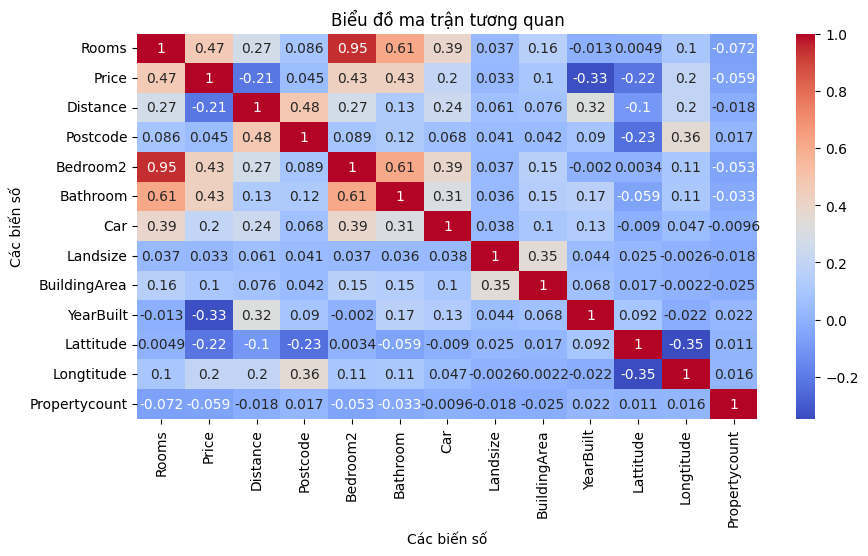

In [23]:
plt.figure(figsize=(10,5))
sns.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm')
plt.title('Biểu đồ ma trận tương quan')
plt.xlabel('Các biến số')
plt.ylabel('Các biến số')
plt.show()

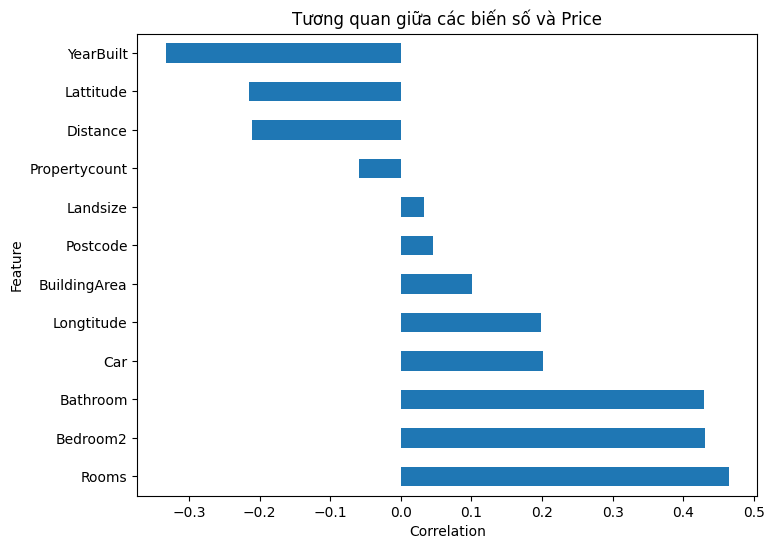

In [24]:
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
corr_with_price = corr_with_price.drop('Price')
plt.figure(figsize=(8,6))
corr_with_price.plot(kind = 'barh')
plt.title('Tương quan giữa các biến số và Price')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

Kết quả tương quan với `Price` cho thấy một số biến như `Rooms`, `Bedroom2`, `Bathroom`, `Car` và `BuildingArea` có tương quan dương với giá nhà. Điều này phù hợp với trực giác vì nhà có nhiều phòng hơn, nhiều tiện ích hơn hoặc diện tích xây dựng lớn hơn thường có giá cao hơn.

Ngoài ra, `Longtitude` cũng có tương quan dương với `Price`, tuy nhiên đây là biến tọa độ địa lý nên cần được hiểu như một yếu tố liên quan đến vị trí không gian của bất động sản, thay vì một đặc trưng vật lý trực tiếp của căn nhà.

Ngược lại, `Distance` có tương quan âm với `Price`, cho thấy các bất động sản ở xa trung tâm hơn thường có xu hướng giá thấp hơn. Các biến như `YearBuilt` và `Lattitude` cũng có tương quan âm với `Price`, nhưng cần diễn giải thận trọng vì chúng có thể chịu ảnh hưởng bởi vị trí, khu vực và loại nhà. Nhìn chung, hệ số tương quan chỉ phản ánh quan hệ tuyến tính từng cặp biến, nên chưa đủ để kết luận quan hệ nhân quả.

## 2.10. Phát hiện outliers
Trong phần này, nhóm sử dụng phương pháp IQR để phát hiện các giá trị ngoại lai ở một số biến quan trọng. Outliers là các giá trị nằm xa phần lớn dữ liệu và có thể ảnh hưởng mạnh đến mô hình OLS, vì OLS tối thiểu hóa tổng bình phương sai số nên nhạy với các quan sát có giá trị quá lớn.

Nhóm tập trung kiểm tra outliers trên các biến `Price`, `Rooms`, `Distance`, `Landsize` và `BuildingArea`. Đây là các biến định lượng có ý nghĩa trực tiếp trong bài toán giá nhà.

Trong đó, `Price` là biến mục tiêu nên outliers ở biến này có thể ảnh hưởng trực tiếp đến mô hình. `Landsize` và `BuildingArea` thường có phân phối lệch phải trong dữ liệu bất động sản, do một số căn nhà có diện tích rất lớn. `Rooms` và `Distance` cũng được kiểm tra vì đây là các đặc trưng cơ bản liên quan đến giá nhà.

Các biến như `Postcode`, `Lattitude` và `Longtitude` tuy có kiểu dữ liệu số nhưng mang ý nghĩa mã khu vực hoặc tọa độ địa lý, nên việc xem outlier bằng IQR không trực tiếp mang ý nghĩa giống các biến định lượng thông thường.

In [25]:
outlier_cols = ["Price", "Rooms", "Distance", "Landsize", "BuildingArea"]

Phương pháp IQR xác định outliers dựa trên khoảng tứ phân vị:

- Q1 là phân vị 25%.
- Q3 là phân vị 75%.
- IQR = Q3 - Q1.

Một giá trị được xem là outlier nếu nhỏ hơn `Q1 - 1.5 * IQR` hoặc lớn hơn `Q3 + 1.5 * IQR`.

In [26]:
def count_outliers_iqr(data, col):
    data_col = data[col].dropna()

    Q1 = data_col.quantile(0.25)
    Q3 = data_col.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_col[(data_col < lower_bound) | (data_col > upper_bound)]

    return len(outliers), lower_bound, upper_bound

In [27]:
outlier_summary = []

for col in outlier_cols:
    if col in df.columns:
        count, lower, upper = count_outliers_iqr(df, col)

        outlier_summary.append({
            "Column": col,
            "Outlier Count": count,
            "Lower Bound": lower,
            "Upper Bound": upper
        })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary["Outlier Percent (%)"] = (
    outlier_summary["Outlier Count"] / len(df) * 100
)
outlier_summary

,Column,Outlier Count,Lower Bound,Upper Bound,Outlier Percent (%)
0,Price,1278,-355000.0,2285000.0,3.666514
1,Rooms,33,-1.0,7.0,0.094675
2,Distance,1467,-5.0,25.4,4.208745
3,Landsize,594,-445.0,1339.0,1.704154
4,BuildingArea,624,-27.0,317.0,1.790223


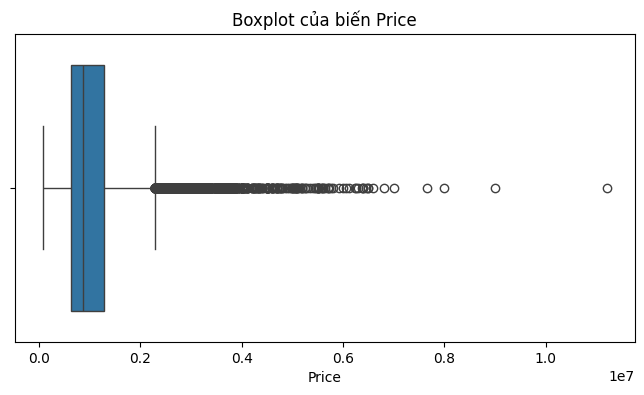

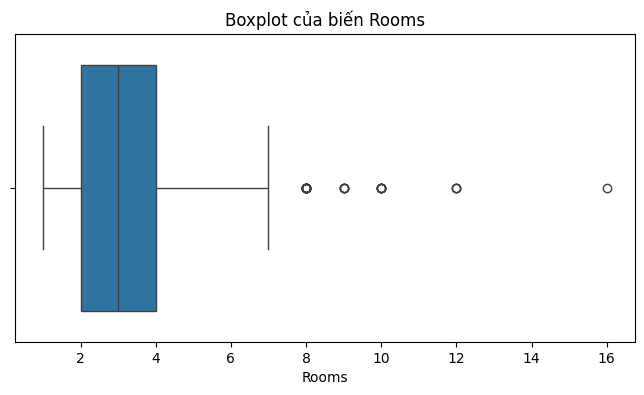

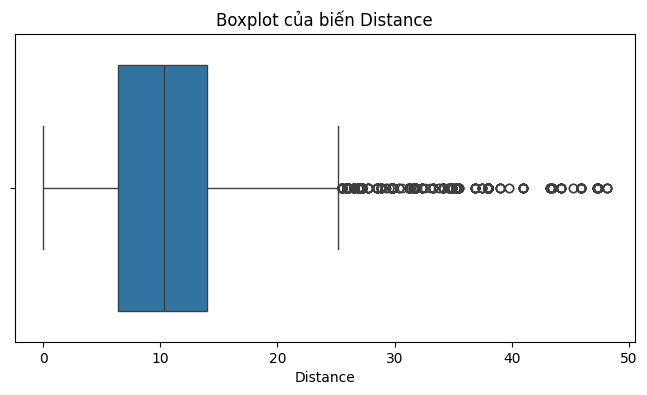

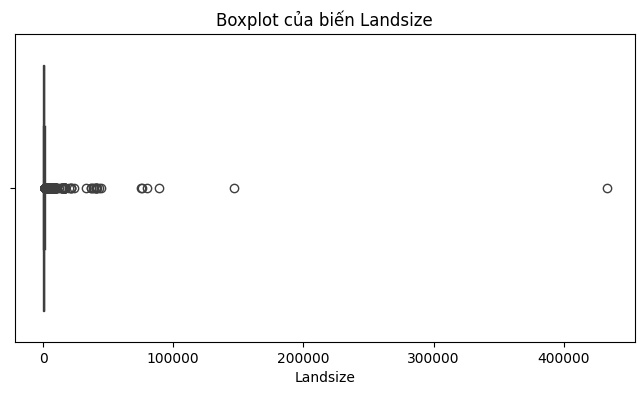

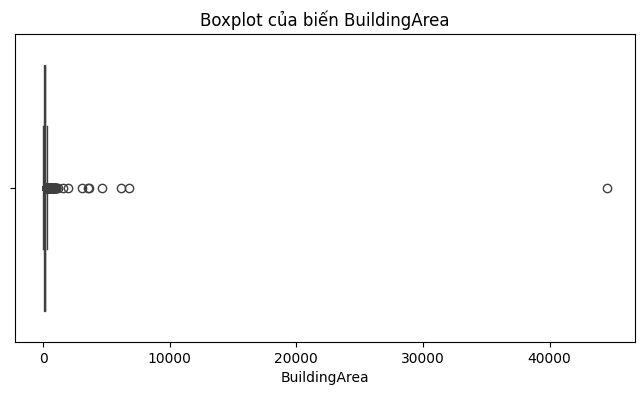

In [28]:
for col in outlier_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f"Boxplot của biến {col}")
        plt.xlabel(col)
        plt.show()

Kết quả boxplot và bảng IQR cho thấy nhiều biến số xuất hiện giá trị ngoại lai, chủ yếu ở phía giá trị lớn. Trong đó, `Price` có nhiều outliers, phản ánh sự tồn tại của một số bất động sản có giá bán cao hơn đáng kể so với mặt bằng chung. Các biến `Landsize` và `BuildingArea` cũng có outliers rất rõ rệt, bao gồm một số giá trị cực lớn; đây có thể là các bất động sản có diện tích đặc biệt lớn hoặc cũng có khả năng là giá trị bất thường trong dữ liệu.

Bên cạnh đó, `Distance` có nhiều outliers ở phía phải, cho thấy một số bất động sản nằm xa trung tâm hơn phần lớn các quan sát còn lại. Biến `Rooms` có ít outliers hơn, chủ yếu là các căn nhà có số phòng lớn hơn thông thường.

Nhìn chung, các outliers này có thể ảnh hưởng đến mô hình hồi quy tuyến tính, đặc biệt là OLS, vì OLS tối thiểu hóa tổng bình phương sai số nên khá nhạy với các quan sát có giá trị cực lớn. Trong phạm vi mô hình hiện tại, nhóm chưa loại bỏ trực tiếp các outliers để tránh làm mất thông tin về các bất động sản có giá trị hoặc diện tích đặc biệt lớn. Tuy nhiên, sự xuất hiện của nhiều outliers, đặc biệt ở `Price`, `Landsize` và `BuildingArea`, có thể là một nguyên nhân khiến RMSE còn tương đối cao ở các mô hình hồi quy tuyến tính.

## 2.11. Tổng kết EDA và định hướng tiền xử lý


Sau quá trình khảo sát dữ liệu, nhóm nhận thấy bộ dữ liệu có một số vấn đề cần xử lý trước khi xây dựng mô hình hồi quy. Các vấn đề chính bao gồm missing values, dữ liệu trùng lặp, biến phân loại, các cột có số lượng nhóm quá lớn, sự khác biệt về thang đo giữa các biến và sự xuất hiện của outliers.

Dựa trên các kết quả EDA ở trên, nhóm đưa ra các quyết định tiền xử lý như sau:

| Vấn đề quan sát được | Hướng xử lý |
|---|---|
| Biến mục tiêu `Price` có missing values | Loại bỏ các dòng thiếu `Price` vì không thể huấn luyện mô hình nếu không có giá trị mục tiêu |
| Dữ liệu có dòng trùng lặp | Loại bỏ các dòng trùng lặp bằng `drop_duplicates()` trước khi tách `X` và `y` |
| Các biến số có missing values | Điền missing values bằng median của từng cột, được tính trên tập train |
| Các biến phân loại có missing values | Điền missing values bằng giá trị `"Unknown"` |
| Dữ liệu gồm cả cột số và cột phân loại | Giữ các cột số sau khi xử lý missing values; chuyển các cột phân loại sang dạng số bằng one-hot encoding |
| Một số biến phân loại có quá nhiều nhóm | Loại bỏ `Address`, `SellerG`, `Suburb` và `Date` trong mô hình cơ bản |
| Các biến có thang đo khác nhau | Chuẩn hóa các đặc trưng bằng z-score |
| Một số cột sau one-hot có thể constant hoặc trùng nhau | Loại bỏ các cột constant và duplicate columns trong `DataPipeline` |
| Dữ liệu có nhiều outliers, đặc biệt ở `Price`, `Distance`, `Landsize`, `BuildingArea` | Không loại bỏ trực tiếp outliers trong phạm vi mô hình hiện tại để tránh mất thông tin; ghi nhận đây là một nguyên nhân có thể làm RMSE cao |

Các quyết định trên được hiện thực hóa trong class `DataPipeline`. Pipeline sẽ được fit trên tập train để học các thống kê như median, mean, standard deviation và danh sách cột sau one-hot encoding. Sau đó, pipeline được dùng để transform tập test bằng đúng các thông tin đã học từ train, nhằm tránh data leakage.

Trong phần tiếp theo, nhóm sẽ tiến hành loại bỏ các dòng thiếu `Price`, tách dữ liệu thành biến đặc trưng `X` và biến mục tiêu `y`, chia train/test, sau đó áp dụng `DataPipeline` để tiền xử lý dữ liệu trước khi xây dựng mô hình.

# 3. Tiền xử lý dữ liệu bằng DataPipeline
Sau bước EDA, nhóm tiến hành tiền xử lý dữ liệu trước khi xây dựng mô hình hồi quy. Các bước tiền xử lý bao gồm loại bỏ các dòng không có biến mục tiêu, tách biến đặc trưng và biến mục tiêu, chia train/test, xử lý missing values, mã hóa biến phân loại, loại bỏ các cột không phù hợp và chuẩn hóa dữ liệu.

Để tránh data leakage, pipeline chỉ được fit trên tập train. Sau đó, tập test được transform bằng các thông tin đã học từ tập train.

In [29]:
df_model = df.copy()
df_model = df_model.dropna(subset = ['Price'])

Vì `Price` là biến mục tiêu của bài toán hồi quy, các dòng thiếu `Price` không thể được sử dụng để huấn luyện hoặc đánh giá mô hình. Do đó, nhóm loại bỏ các dòng này trước khi tách dữ liệu thành `X` và `y`.

In [30]:
X = df_model.drop('Price', axis = 1)
y = df_model['Price']

Nhóm chọn `Price` làm biến mục tiêu. Các cột còn lại được xem là biến đặc trưng đầu vào. Một số cột không phù hợp như `Address`, `SellerG`, `Date` và `Suburb` sẽ được loại bỏ trong `DataPipeline`.

In [31]:
train_data = df_model.sample(frac=0.8, random_state=0)
test_data = df_model.drop(train_data.index)
X_train = train_data.drop("Price", axis=1)
y_train = train_data["Price"]

X_test = test_data.drop("Price", axis=1)
y_test = test_data["Price"]

Dữ liệu được chia thành tập train và test theo tỉ lệ 80/20 bằng pandas. Tham số `random_state=0` được sử dụng để đảm bảo kết quả có thể tái lập.

In [32]:
pipeline = DataPipeline(drop_columns = ['Address', 'SellerG', 'Date', 'Suburb', 'CouncilArea'])
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)


Pipeline được fit trên `X_train` để học median của các cột số, danh sách cột sau one-hot encoding, mean và standard deviation dùng cho chuẩn hóa. Sau đó, cùng pipeline này được dùng để transform `X_test`, đảm bảo tập test không bị sử dụng trong quá trình học thống kê tiền xử lý.

In [33]:
print("Shape X_train_processed:", X_train_processed.shape)
print("Shape X_test_processed:", X_test_processed.shape)

print("Missing train:", X_train_processed.isnull().sum().sum())
print("Missing test:", X_test_processed.isnull().sum().sum())

print("Train/test cùng số cột:", X_train_processed.shape[1] == X_test_processed.shape[1])

Shape X_train_processed: (21798, 26)
Shape X_test_processed: (5449, 26)
Missing train: 0
Missing test: 0
Train/test cùng số cột: True


Sau khi áp dụng `DataPipeline`, dữ liệu train và test không còn missing values, toàn bộ biến đã được chuyển sang dạng số và hai tập dữ liệu có cùng số lượng cột. Điều này cho thấy pipeline đã xử lý nhất quán giữa train và test, phù hợp để đưa vào các mô hình hồi quy.

In [34]:
print(f'Các constant là: {pipeline.constant_cols}')
print(f'Các trùng nhau hoàn toàn sau one-hot là: {pipeline.duplicate_cols}')

Các constant là: []
Các trùng nhau hoàn toàn sau one-hot là: []


Sau khi one-hot encoding, pipeline không phát hiện cột constant nào và không loại bỏ thêm cột dummy quan trọng nào khỏi tập đặc trưng cuối cùng. Điều này cho thấy các bước xử lý trước đó như `drop_first=True` trong one-hot encoding và loại bỏ các cột không phù hợp đã giúp giảm bớt rủi ro tạo ra các cột dư thừa.

Việc kiểm tra các cột constant và các cột trùng nhau vẫn cần thiết vì các cột này không cung cấp thêm thông tin cho mô hình, đồng thời có thể làm tăng nguy cơ đa cộng tuyến hoặc khiến ma trận thiết kế kém ổn định khi huấn luyện OLS.

# 4. Xây dựng và so sánh mô hình

Sau khi dữ liệu đã được tiền xử lý bằng `DataPipeline`, nhóm tiến hành xây dựng và so sánh ba mô hình hồi quy tuyến tính:

1. **OLS cơ bản**: sử dụng toàn bộ các biến sau tiền xử lý.
2. **OLS chọn biến bằng VIF**: loại bỏ các biến có đa cộng tuyến cao dựa trên ngưỡng VIF.
3. **Ridge Regression**: sử dụng regularization L2, trong đó tham số λ được chọn bằng k-fold cross-validation.

Các mô hình được đánh giá trên tập test bằng ba độ đo: MAE, RMSE và R².

In [ ]:
import sys
import os

# Thư mục hiện tại: part 2
PART2_DIR = os.getcwd()

# Thư mục gốc
BASE_DIR = os.path.abspath("..")

# Thư mục chứa code phần 1
PART1_DIR = os.path.join(BASE_DIR, "part1")

# Thêm đủ đường dẫn để Python tìm thấy module
for path in [PART2_DIR, BASE_DIR, PART1_DIR]:
    if path not in sys.path:
        sys.path.insert(0, path)

from model_comparison import run_ols_basic, run_ols_selected_by_vif, run_ridge_cv

from linalg_utils import transpose, matmul, matvec, mat_add, mat_scale, eye, inv
from residual_analysis import cooks_distance, norm_ppf

## 4.1. Mô hình 1: OLS cơ bản

Mô hình OLS cơ bản sử dụng toàn bộ các biến sau khi đã được tiền xử lý. Đây là mô hình nền để so sánh với các mô hình có chọn biến hoặc regularization.

In [36]:
ols_basic_result = run_ols_basic(X_train_processed, y_train, X_test_processed, y_test)
ols_basic_result['metrics']

{'MAE': 274295.17736092303,
 'RMSE': 480048.78214204044,
 'R2': 0.43670942046564565}

Mô hình OLS cơ bản được huấn luyện trên toàn bộ đặc trưng sau tiền xử lý và đánh giá trên tập test. Kết quả này được dùng làm baseline cho các mô hình tiếp theo.

## 4.2. Mô hình 2: OLS chọn biến bằng VIF

Mô hình OLS cơ bản sử dụng toàn bộ các biến sau tiền xử lý, do đó có thể chịu ảnh hưởng của hiện tượng đa cộng tuyến giữa các đặc trưng. Để kiểm tra ảnh hưởng của việc chọn biến, nhóm xây dựng thêm một mô hình OLS sử dụng VIF (Variance Inflation Factor) để loại bỏ các biến có mức đa cộng tuyến cao.

Trong phần này, nhóm chọn ngưỡng VIF = 3 thay vì ngưỡng phổ biến là 10. Việc sử dụng ngưỡng nhỏ hơn giúp quá trình chọn biến nghiêm ngặt hơn, từ đó tạo ra một tập đặc trưng khác biệt rõ hơn so với mô hình OLS cơ bản. Mục tiêu của mô hình này không chỉ là cải thiện hiệu năng, mà còn là đánh giá xem việc loại bỏ mạnh các biến đa cộng tuyến có làm mô hình ổn định hơn hay làm mất đi thông tin dự đoán quan trọng.

In [37]:
ols_selected_result = run_ols_selected_by_vif(X_train_processed,
                                              y_train,
                                              X_test_processed,
                                              y_test,
                                              threshold = 3)
ols_selected_result['metrics']

{'MAE': 309737.11637708417,
 'RMSE': 582088.8262387634,
 'R2': 0.17179038328586327}

In [38]:
print("Các feature giữ lại là:")
for feature in ols_selected_result["selected_features"]:
    print("-", feature)

Các feature giữ lại là:
- Longtitude
- Distance
- Method_S
- Lattitude
- Regionname_South-Eastern Metropolitan
- Postcode
- Method_SP
- Type_u
- Method_VB
- Bathroom
- Regionname_Northern Victoria
- Regionname_Western Victoria
- Regionname_Eastern Victoria
- YearBuilt
- Car
- Type_t
- Propertycount
- BuildingArea
- Method_SA
- Landsize
- Regionname_Unknown


In [39]:
ols_selected_result['vif_table']

,Feature,VIF
24,Regionname_Western Metropolitan,4.383766
0,Rooms,4.008293
3,Bedroom2,3.739879
22,Regionname_Southern Metropolitan,3.711515
19,Regionname_Northern Metropolitan,3.667996
10,Longtitude,2.619296
1,Distance,2.576723
14,Method_S,2.318095
9,Lattitude,2.040460
21,Regionname_South-Eastern Metropolitan,1.970645


## 4.3. Mô hình 3: Ridge Regression chọn λ bằng Cross-Validation

Ridge Regression thêm thành phần regularization L2 vào hàm mất mát nhằm giảm ảnh hưởng của đa cộng tuyến và giúp mô hình ổn định hơn. Tham số λ được chọn bằng k-fold cross-validation trên tập train.

In [40]:
lambdas = [0.01, 0.1, 1, 10, 100, 1000]

In [41]:
ridge_result = run_ridge_cv(X_train_processed, y_train, X_test_processed, y_test, lambdas, k = 5, seed = 42)
ridge_result["metrics"] = {
    key: float(value)
    for key, value in ridge_result["metrics"].items()
}
ridge_result['metrics']

{'MAE': 274187.6416699455, 'RMSE': 480021.5627024699, 'R2': 0.4367732973872205}

In [42]:
ridge_result["best_lambda"] = float(ridge_result["best_lambda"])
ridge_result['best_lambda']

10.0

In [43]:
ridge_result["cv_results"]

,lambda,CV_MSE
0,0.01,1.774925e+11
1,0.10,1.774925e+11
2,1.00,1.774919e+11
3,10.00,1.774872e+11
4,100.00,1.774914e+11
5,1000.00,1.815859e+11


Mỗi giá trị λ được đánh giá bằng 5-fold cross-validation trên tập train. Giá trị λ có CV_MSE nhỏ nhất được chọn để huấn luyện mô hình Ridge cuối cùng trên toàn bộ tập train.

## 4.4. Bảng so sánh kết quả

In [44]:
comparison_table = pd.DataFrame([
    {
        "Model": ols_basic_result["model_name"],
        "MAE": ols_basic_result["metrics"]["MAE"],
        "RMSE": ols_basic_result["metrics"]["RMSE"],
        "R2": ols_basic_result["metrics"]["R2"],
        "Best Lambda": None,
        "Num Features": X_train_processed.shape[1]
    },
    {
        "Model": ols_selected_result["model_name"],
        "MAE": ols_selected_result["metrics"]["MAE"],
        "RMSE": ols_selected_result["metrics"]["RMSE"],
        "R2": ols_selected_result["metrics"]["R2"],
        "Best Lambda": None,
        "Num Features": len(ols_selected_result["selected_features"])
    },
    {
        "Model": ridge_result["model_name"],
        "MAE": ridge_result["metrics"]["MAE"],
        "RMSE": ridge_result["metrics"]["RMSE"],
        "R2": ridge_result["metrics"]["R2"],
        "Best Lambda": ridge_result["best_lambda"],
        "Num Features": X_train_processed.shape[1]
    }
])

comparison_table

,Model,MAE,RMSE,R2,Best Lambda,Num Features
0,OLS Basic,274295.177361,480048.782142,0.436709,NaN,26
1,OLS Selected by VIF,309737.116377,582088.826239,0.171790,NaN,21
2,Ridge Regression,274187.641670,480021.562702,0.436773,10.0,26


## 4.5. Nhận xét kết quả

Dựa trên bảng kết quả, Ridge Regression là mô hình có hiệu năng tốt nhất, tuy nhiên mức cải thiện so với OLS cơ bản là rất nhỏ. Cụ thể, RMSE của Ridge chỉ thấp hơn OLS cơ bản một lượng không đáng kể, trong khi R² gần như tương đương. Điều này cho thấy regularization L2 có thể giúp hạn chế ảnh hưởng của đa cộng tuyến, nhưng trong thí nghiệm này chưa tạo ra sự cải thiện lớn về khả năng dự đoán trên tập test.

Ngược lại, mô hình OLS chọn biến bằng VIF cho kết quả kém hơn rõ rệt so với OLS cơ bản. Nguyên nhân có thể đến từ việc nhóm sử dụng ngưỡng VIF = 3, một ngưỡng tương đối nghiêm ngặt. Cách chọn này giúp mô hình VIF khác biệt rõ hơn với OLS cơ bản, nhưng đồng thời cũng có thể loại bỏ một số biến vẫn còn chứa thông tin quan trọng cho việc dự đoán giá nhà. Vì vậy, kết quả này cho thấy việc giảm đa cộng tuyến không phải lúc nào cũng làm tăng hiệu năng dự đoán, đặc biệt khi tiêu chí chọn biến quá chặt.

Từ kết quả thực nghiệm, nhóm chọn Ridge Regression là mô hình phù hợp nhất trong ba mô hình được so sánh. Tuy nhiên, OLS cơ bản cũng cho hiệu năng gần tương đương, trong khi OLS chọn biến bằng VIF cho thấy hạn chế của việc loại bỏ biến quá mạnh.

## 4.6. Phân tích phần dư của mô hình tốt nhất

Sau khi so sánh ba mô hình, nhóm chọn **Ridge Regression** là mô hình phù hợp nhất để phân tích sâu hơn. Trong phần này, nhóm phân tích phần dư của mô hình Ridge trên tập test nhằm đánh giá xem sai số dự đoán có phân bố hợp lý hay không.

Các biểu đồ chẩn đoán chính được sử dụng gồm:

- **Residuals vs Fitted**: kiểm tra xu hướng phi tuyến hoặc sai số có hệ thống.
- **Q-Q Plot**: kiểm tra mức độ gần với phân phối chuẩn của phần dư.
- **Scale-Location Plot**: kiểm tra sự thay đổi phương sai theo giá trị dự đoán.
- **Cook's Distance**: xác định các quan sát có ảnh hưởng lớn đến mô hình.

Ngoài ra, nhóm sử dụng biểu đồ **Histogram of Residuals** như một biểu đồ phụ để quan sát thêm hình dạng phân phối sai số.

In [45]:
y_test_list = y_test.tolist() if hasattr(y_test, "tolist") else y_test

ridge_y_pred = ridge_result["y_pred"]
ridge_residuals = [
    y_test_list[i] - ridge_y_pred[i]
    for i in range(len(y_test_list))
]

residual_summary = pd.DataFrame({
    "Metric": ["Mean", "Median", "Std", "Min", "Max"],
    "Value": [
        sum(ridge_residuals) / len(ridge_residuals),
        pd.Series(ridge_residuals).median(),
        pd.Series(ridge_residuals).std(),
        min(ridge_residuals),
        max(ridge_residuals)
    ]
})

residual_summary

,Metric,Value
0,Mean,-2.749750e+03
1,Median,-5.225348e+04
2,Std,4.800577e+05
3,Min,-1.869236e+07
4,Max,4.866318e+06


In [57]:
import math

def to_list_matrix(X):
    if hasattr(X, "values"):
        return X.values.tolist()
    return X

def to_list_vector(y):
    if hasattr(y, "tolist"):
        return y.tolist()
    return y

def add_intercept_for_matrix(X):
    X_list = to_list_matrix(X)
    return [[1.0] + list(row) for row in X_list]

def ridge_leverages_in_sample(X_train_ridge, lam):
    """
    Tính leverage cho Ridge trên chính tập train:
        h_i = x_i^T (X^T X + λI)^(-1) x_i

    Không dùng numpy.
    """
    Xt = transpose(X_train_ridge)
    XtX = matmul(Xt, X_train_ridge)

    p = len(X_train_ridge[0])
    XtX_reg = mat_add(XtX, mat_scale(eye(p), lam))
    XtX_reg_inv = inv(XtX_reg)

    h = []
    for x in X_train_ridge:
        A_inv_x = matvec(XtX_reg_inv, x)
        h_i = sum(x[j] * A_inv_x[j] for j in range(p))

        # Chỉ chặn lỗi số học nhỏ
        if h_i < 0:
            h_i = 0.0
        if h_i >= 1:
            h_i = 0.999999

        h.append(h_i)

    return h


# Dùng TRAIN để phân tích phần dư
X_diag = add_intercept_for_matrix(X_train_processed)
y_diag = to_list_vector(y_train)

beta_diag = ridge_result["beta"]
best_lambda = ridge_result["best_lambda"]

y_diag_pred = matvec(X_diag, beta_diag)

ridge_residuals = [
    y_diag[i] - y_diag_pred[i]
    for i in range(len(y_diag))
]

n_diag = len(y_diag)
p_diag = len(beta_diag)

ridge_leverage = ridge_leverages_in_sample(X_diag, best_lambda)

rss_diag = sum(ei * ei for ei in ridge_residuals)
sigma2_diag = rss_diag / max(n_diag - p_diag, 1)

ridge_std_residuals = []
for i in range(n_diag):
    denom = math.sqrt(sigma2_diag) * math.sqrt(max(1.0 - ridge_leverage[i], 1e-12))
    ridge_std_residuals.append(ridge_residuals[i] / denom)

ridge_cooks = cooks_distance(ridge_std_residuals, ridge_leverage, p_diag)
cook_threshold = 4 / n_diag

print("n =", n_diag)
print("p =", p_diag)
print("Best lambda =", best_lambda)
print("Max standardized residual =", max(ridge_std_residuals))
print("Min standardized residual =", min(ridge_std_residuals))
print("Max Cook's Distance =", max(ridge_cooks))
print("Cook threshold = 4/n =", cook_threshold)

n = 21798
p = 27
Best lambda = 10.0
Max standardized residual = 22.044502357380082
Min standardized residual = -8.295460385274922
Max Cook's Distance = 2.3476343789874368
Cook threshold = 4/n = 0.00018350307367648408


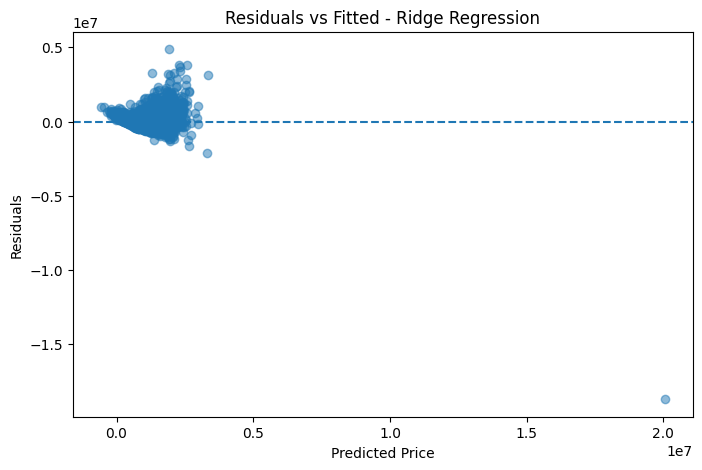

In [55]:
plt.figure(figsize=(8, 5))
plt.scatter(ridge_y_pred, ridge_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted - Ridge Regression")
plt.show()

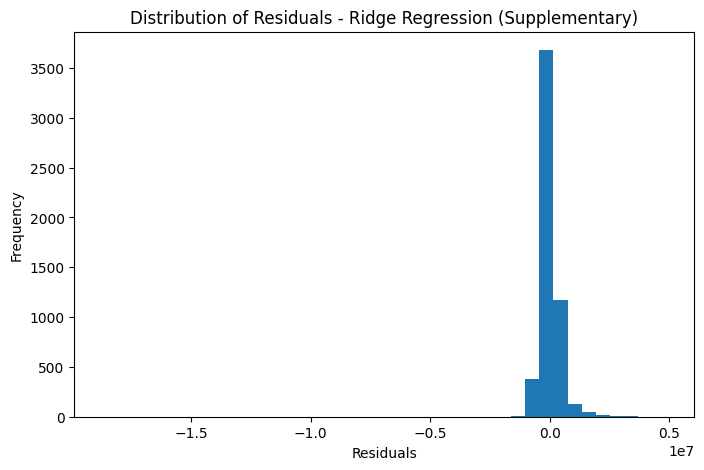

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(ridge_residuals, bins=40)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Ridge Regression (Supplementary)")
plt.show()

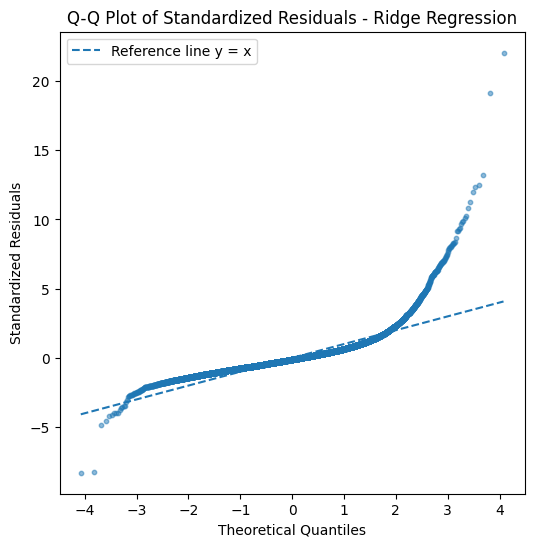

In [58]:
qq_residuals = sorted(ridge_std_residuals)
n_qq = len(qq_residuals)

theoretical_quantiles = [
    norm_ppf((i + 0.5) / n_qq)
    for i in range(n_qq)
]

plt.figure(figsize=(6, 6))
plt.scatter(theoretical_quantiles, qq_residuals, alpha=0.5, s=10)

x_min = theoretical_quantiles[0]
x_max = theoretical_quantiles[-1]

plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    linestyle="--",
    label="Reference line y = x"
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.title("Q-Q Plot of Standardized Residuals - Ridge Regression")
plt.legend()
plt.show()

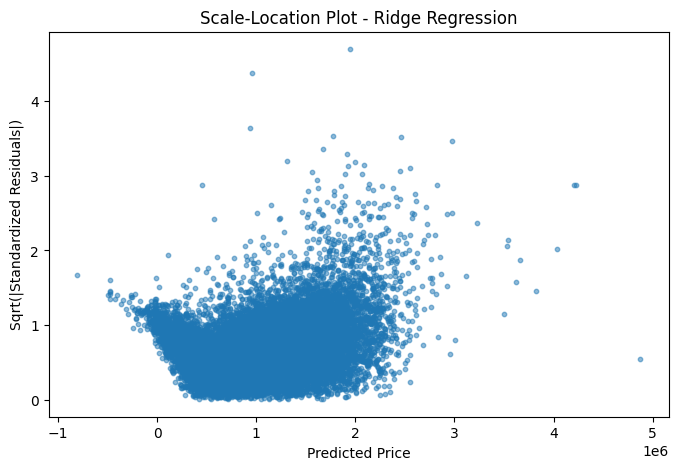

In [59]:
sqrt_abs_standardized_residuals = [
    math.sqrt(abs(ri))
    for ri in ridge_std_residuals
]

plt.figure(figsize=(8, 5))
plt.scatter(y_diag_pred, sqrt_abs_standardized_residuals, alpha=0.5, s=10)

plt.xlabel("Predicted Price")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot - Ridge Regression")
plt.show()

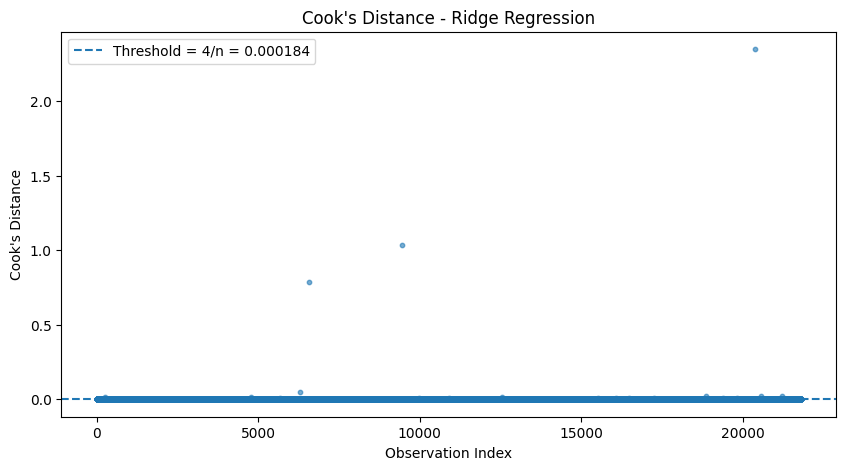

In [60]:
plt.figure(figsize=(10, 5))
plt.scatter(range(n_diag), ridge_cooks, alpha=0.6, s=10)

plt.axhline(
    cook_threshold,
    linestyle="--",
    label=f"Threshold = 4/n = {cook_threshold:.6f}"
)

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance - Ridge Regression")
plt.legend()
plt.show()

In [61]:
# Bảng kiểm tra các điểm vượt ngưỡng
influential_points = []

for i in range(n_diag):
    if ridge_cooks[i] > cook_threshold:
        influential_points.append({
            "Observation Index": i,
            "Residual": ridge_residuals[i],
            "Standardized Residual": ridge_std_residuals[i],
            "Leverage": ridge_leverage[i],
            "Cook's Distance": ridge_cooks[i]
        })

influential_table = pd.DataFrame(influential_points)
influential_table = influential_table.sort_values("Cook's Distance", ascending=False)

influential_table.head(10)

,Observation Index,Residual,Standardized Residual,Leverage,Cook's Distance
757,20367,-8.345486e+05,-4.232893,0.779623,2.347634
348,9449,-2.929392e+06,-8.277880,0.290008,1.036648
241,6587,-3.044637e+06,-8.295460,0.236293,0.788573
235,6308,-1.614051e+06,-4.002319,0.077965,0.050166
768,20547,1.084152e+06,2.679595,0.071934,0.020612
798,21205,8.040866e+06,19.160147,0.001508,0.020532
701,18858,5.022476e+06,11.979353,0.003435,0.018319
8,258,-2.026696e+06,-4.875215,0.020225,0.018171
172,4785,9.254205e+06,22.044502,0.000888,0.015988
451,12549,-1.018209e+06,-2.496374,0.056827,0.013907


### Nhận xét phân tích phần dư

Nhìn chung, kết quả phân tích phần dư cho thấy mô hình **Ridge Regression** hoạt động tương đối ổn, nhưng vẫn còn một số hạn chế nhất định.

**1. Residuals vs Fitted**

Biểu đồ Residuals vs Fitted cho thấy phần dư của mô hình chủ yếu phân tán quanh mức 0. Điều này cho thấy mô hình không có xu hướng dự đoán lệch hoàn toàn về một phía. Tuy nhiên, vẫn còn một số điểm có sai số khá lớn, đặc biệt ở các bất động sản có giá trị dự đoán cao. Điều này phù hợp với kết quả EDA trước đó, khi biến `Price` có phân phối lệch phải mạnh và tồn tại nhiều outliers.

**2. Q-Q Plot**

Q-Q Plot cho thấy phần dư chuẩn hóa tương đối gần đường tham chiếu ở vùng trung tâm, nhưng lệch rõ hơn ở hai đuôi. Điều này cho thấy phần dư chưa hoàn toàn tuân theo phân phối chuẩn. Đây là hiện tượng khá thường gặp trong dữ liệu bất động sản, vì giá nhà chịu ảnh hưởng bởi nhiều yếu tố khó quan sát và có nhiều giá trị ngoại lệ.

**3. Scale-Location Plot**

Scale-Location Plot cho thấy độ lớn của phần dư không hoàn toàn ổn định trên toàn bộ miền giá trị dự đoán. Một số vùng có phần dư chuẩn hóa lớn hơn, gợi ý khả năng tồn tại hiện tượng phương sai thay đổi. Điều này cho thấy mô hình tuyến tính vẫn còn hạn chế trong việc mô tả đầy đủ mối quan hệ giữa các đặc trưng và giá nhà.

**4. Cook's Distance**

Cook's Distance được sử dụng để kiểm tra các quan sát có khả năng ảnh hưởng lớn đến mô hình. Kết quả cho thấy một số quan sát có Cook's Distance vượt ngưỡng tham khảo `4/n`, nghĩa là các điểm này cần được chú ý vì chúng thường kết hợp giữa phần dư lớn và leverage cao. Những quan sát này có thể là các căn nhà có giá, diện tích, vị trí hoặc đặc điểm khác biệt đáng kể so với phần lớn dữ liệu.

Do đó, nếu tiếp tục cải thiện mô hình, nhóm có thể kiểm tra kỹ hơn các điểm này, so sánh với bước EDA ban đầu, hoặc thử các mô hình bền vững hơn với outliers. Tuy nhiên, nhóm không loại bỏ trực tiếp các điểm này trong mô hình chính, vì chúng có thể phản ánh các trường hợp thực tế đặc biệt của thị trường bất động sản.

**5. Histogram of Residuals**

Histogram phần dư được giữ lại như một biểu đồ phụ để quan sát thêm hình dạng phân phối sai số. Biểu đồ cho thấy phần dư tập trung quanh 0, tức là mô hình không bị lệch hệ thống quá nghiêm trọng. Tuy nhiên, phần đuôi vẫn còn kéo dài, phản ánh sự tồn tại của một số sai số lớn trong dữ liệu giá nhà.

**Kết luận chung**

Trong phạm vi ba mô hình đã so sánh, **Ridge Regression** cho kết quả tốt nhất và có thể được xem là một baseline tương đối ổn cho bài toán dự đoán giá nhà. Tuy nhiên, phân tích phần dư cho thấy mô hình vẫn chưa xử lý hoàn toàn tốt các đặc điểm phức tạp của dữ liệu bất động sản. Cụ thể, dữ liệu vẫn tồn tại outliers, phần dư chưa hoàn toàn tuân theo phân phối chuẩn và có dấu hiệu phương sai thay đổi.

Điều này cho thấy mối quan hệ giữa các đặc trưng và giá nhà có thể không hoàn toàn tuyến tính. Do đó, trong các hướng phát triển tiếp theo, nhóm có thể thử thêm các mô hình phi tuyến, biến đổi log cho biến mục tiêu `Price`, hoặc các phương pháp bền vững hơn với outliers để cải thiện khả năng dự đoán.

## 4.7. Phân tích hệ số hồi quy của mô hình tốt nhất

Vì các đặc trưng đầu vào đã được chuẩn hóa trong pipeline, hệ số hồi quy của mô hình Ridge có thể được sử dụng để so sánh mức độ ảnh hưởng tương đối giữa các biến. Trong phần này, nhóm xét các hệ số có trị tuyệt đối lớn nhất để xác định những đặc trưng đóng góp mạnh nhất vào dự đoán giá nhà.

In [53]:
ridge_coef = ridge_result["beta"][1:]  # bỏ intercept
feature_names = X_train_processed.columns.tolist()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_coef
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

top_coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
).head(20)

top_coef_df

,Feature,Coefficient,Abs_Coefficient
1,Distance,-278963.508507,278963.508507
0,Rooms,235172.611861,235172.611861
13,Type_u,-168493.076274,168493.076274
24,Regionname_Western Metropolitan,-111517.898639,111517.898639
4,Bathroom,102839.491982,102839.491982
22,Regionname_Southern Metropolitan,100233.321279,100233.321279
19,Regionname_Northern Metropolitan,-97849.175781,97849.175781
8,YearBuilt,-67222.976044,67222.976044
12,Type_t,-62216.885478,62216.885478
5,Car,45743.987648,45743.987648


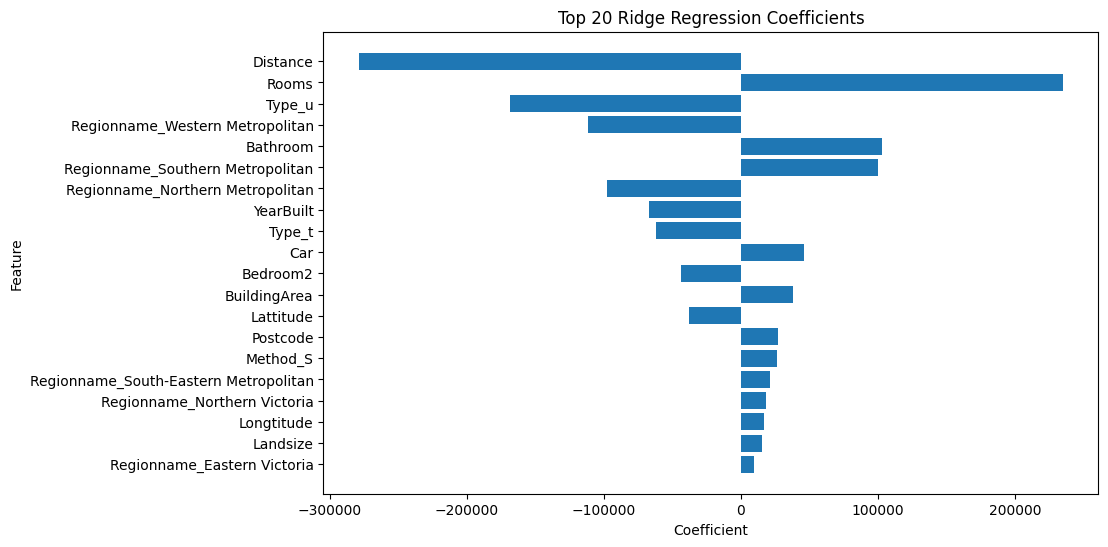

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(
    top_coef_df["Feature"],
    top_coef_df["Coefficient"]
)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Ridge Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

Bảng hệ số và biểu đồ trên cho thấy các biến có trị tuyệt đối hệ số lớn nhất là những biến ảnh hưởng mạnh nhất đến dự đoán của mô hình Ridge. Hệ số dương cho thấy khi giá trị của biến tăng thì giá nhà dự đoán có xu hướng tăng, trong khi hệ số âm cho thấy xu hướng ngược lại.

Do dữ liệu đã được chuẩn hóa, có thể so sánh tương đối độ lớn của các hệ số giữa các biến khác nhau. Tuy nhiên, các hệ số này không nên được hiểu là quan hệ nhân quả tuyệt đối, mà chỉ phản ánh mối liên hệ tuyến tính giữa đặc trưng và giá nhà trong phạm vi mô hình Ridge đã huấn luyện.

Kết quả này giúp bổ sung khả năng giải thích cho mô hình, bên cạnh các chỉ số đánh giá như MAE, RMSE và R².

## 5. Kết luận

Qua quá trình thực nghiệm trên bộ dữ liệu **Melbourne Housing**, nhóm rút ra một số kết luận chính như sau:

1. Bộ dữ liệu có kích thước lớn và phù hợp với bài toán hồi quy dự đoán giá nhà. Tuy nhiên, dữ liệu ban đầu còn tồn tại nhiều vấn đề cần xử lý như missing values, outliers, biến phân loại và sự khác biệt lớn về thang đo giữa các biến. Đặc biệt, các biến như `BuildingArea`, `YearBuilt`, `Landsize`, `Bathroom`, `Car`, `Bedroom2` và cả biến mục tiêu `Price` đều có giá trị thiếu, nên bước tiền xử lý đóng vai trò rất quan trọng trước khi xây dựng mô hình.

2. Kết quả EDA cho thấy `Price`, `Landsize` và `BuildingArea` có phân phối lệch phải mạnh và tồn tại nhiều giá trị ngoại lệ. Đây là đặc điểm khá phổ biến của dữ liệu bất động sản, vì một số căn nhà có giá hoặc diện tích rất lớn so với phần lớn quan sát còn lại. Do đó, nhóm đã tạo thêm các biến như `LogLandsize`, `LogBuildingArea` và phân tích thêm `LogPrice` để giảm ảnh hưởng của outliers và giúp dữ liệu phù hợp hơn với mô hình hồi quy tuyến tính.

3. Nhóm đã xây dựng `DataPipeline` để xử lý dữ liệu theo một quy trình thống nhất, bao gồm: loại bỏ các cột không sử dụng, điền missing values, one-hot encoding biến phân loại, loại bỏ cột constant/duplicate, căn chỉnh cột giữa train/test và chuẩn hóa đặc trưng. Pipeline được fit trên tập train và transform trên tập test, giúp hạn chế data leakage và đảm bảo quá trình đánh giá mô hình khách quan hơn.

4. Kết quả so sánh mô hình cho thấy **OLS Basic/OLS Full** và **Ridge Regression** cho hiệu quả dự đoán tốt hơn so với **OLS Selected by VIF**. OLS Selected có kết quả thấp hơn do việc loại bỏ nhiều biến có thể làm mất thông tin quan trọng, dẫn đến mô hình bị underfitting. Trong khi đó, Ridge có kết quả gần với OLS Full và có ưu điểm là giúp hệ số ổn định hơn khi dữ liệu có nhiều biến sau one-hot encoding hoặc có khả năng tồn tại đa cộng tuyến.

5. Các biến có ảnh hưởng đáng kể đến giá nhà chủ yếu thuộc nhóm đặc điểm vị trí, quy mô căn nhà và loại hình bất động sản. Các biến như `Distance`, `Rooms`, `Bathroom`, `Landsize`, `Type`, `Regionname` và `CouncilArea` đều có ý nghĩa thực tế trong việc giải thích giá nhà. Điều này phù hợp với trực giác thị trường bất động sản, vì giá nhà thường phụ thuộc mạnh vào khoảng cách đến trung tâm, số phòng, diện tích, loại hình nhà và khu vực tọa lạc.

6. ác biểu đồ phân tích phần dư cho thấy mô hình tuyến tính đã nắm bắt được xu hướng chính của dữ liệu, khi phần dư nhìn chung phân tán quanh 0. Tuy nhiên, Q-Q plot và các biểu đồ phần dư vẫn cho thấy sự tồn tại của outliers, phần đuôi phân phối dày và khả năng có quan hệ phi tuyến chưa được mô hình tuyến tính giải thích hết. Vì vậy, mô hình hiện tại phù hợp để làm baseline, nhưng chưa phải là mô hình tối ưu tuyệt đối cho bài toán dự đoán giá nhà.

Nhóm đã xây dựng được một quy trình tương đối hoàn chỉnh từ tiền xử lý dữ liệu, phân tích khám phá, xây dựng mô hình hồi quy, đánh giá mô hình đến phân tích kết quả.